In [1]:
from neuron import h, gui
import sys
sys.path.append("../cells/cell1/")
import os
from neuron_simulation import run_nrnivmodl, extract_template_name, get_hoc_morph_for_emodel_folder, check_line_in_file
import logging

relativepath_cell1 = "../cells/cell1/"
import os
print(os.path.abspath("../cells/cell1/")) # 絶対パスを表示して確認
import os

# 1. 現在の場所を確認
print("Current Working Directory:", os.getcwd())

# 2. 指定したパスの「中身」を一覧表示
target_path = "../cells/cell1/"
if os.path.exists(target_path):
    print(f"Contents of {target_path}:", os.listdir(target_path))
else:
    print(f"Directory {target_path} does not exist.")

# 3. 正しい絶対パスの導出
print("Correct Absolute Path:", os.path.abspath(target_path))

# Check if the mecahnisms folder exsists
if not(os.path.exists(relativepath_cell1 + "mechanisms")):
    logging.error("No mechanisms directory found.")
# Run the command
run_nrnivmodl(relativepath_cell1)
#from neuron import rxd

# Get the hoc file
hoc_path, morph_path = get_hoc_morph_for_emodel_folder(relativepath_cell1)
#Load the standard hoc file and the custom hoc file for the model
h.load_file('stdrun.hoc')
h.load_file(hoc_path.as_posix())
#Extract the template name from the hoc file, and create a cell instance
method_name = extract_template_name(hoc_path.as_posix())
#Based on the number of arguments in the template, initialize the cell.
if check_line_in_file(hoc_path.as_posix(), "gid = $1"):
    cell = getattr(h, method_name)(0, relativepath_cell1 + "morphology",morph_path.name )
else:
    cell = getattr(h, method_name)( relativepath_cell1 + "morphology",morph_path.name )

NEURON: unable to open font "*helvetica-medium-r-normal*--14*", using "fixed"


/home/satoshi/NeuMoReservoir/cells/cell1
Current Working Directory: /home/satoshi/NeuMoReservoir/analysis
Contents of ../cells/cell1/: ['__pycache__', 'README.md', 'morphology', 'mechanisms', 'electrophysiology', 'neuron_simulation.py']
Correct Absolute Path: /home/satoshi/NeuMoReservoir/cells/cell1
Ran command - ['nrnivmodl', '../cells/cell1/mechanisms']
Output: /home/satoshi/NeuMoReservoir/analysis
cfiles =
Mod files: "../cells/cell1/mechanisms/cacum.mod" "../cells/cell1/mechanisms/cagk.mod" "../cells/cell1/mechanisms/cal.mod" "../cells/cell1/mechanisms/can.mod" "../cells/cell1/mechanisms/cat.mod" "../cells/cell1/mechanisms/hd.mod" "../cells/cell1/mechanisms/kad.mod" "../cells/cell1/mechanisms/kap.mod" "../cells/cell1/mechanisms/kca.mod" "../cells/cell1/mechanisms/kdr.mod" "../cells/cell1/mechanisms/kmb.mod" "../cells/cell1/mechanisms/nax.mod"

MODOBJS= ./cacum.o ./cagk.o ./cal.o ./can.o ./cat.o ./hd.o ./kad.o ./kap.o ./kca.o ./kdr.o ./kmb.o ./nax.o
 -> Compiling mod_func.cpp
 => LIN

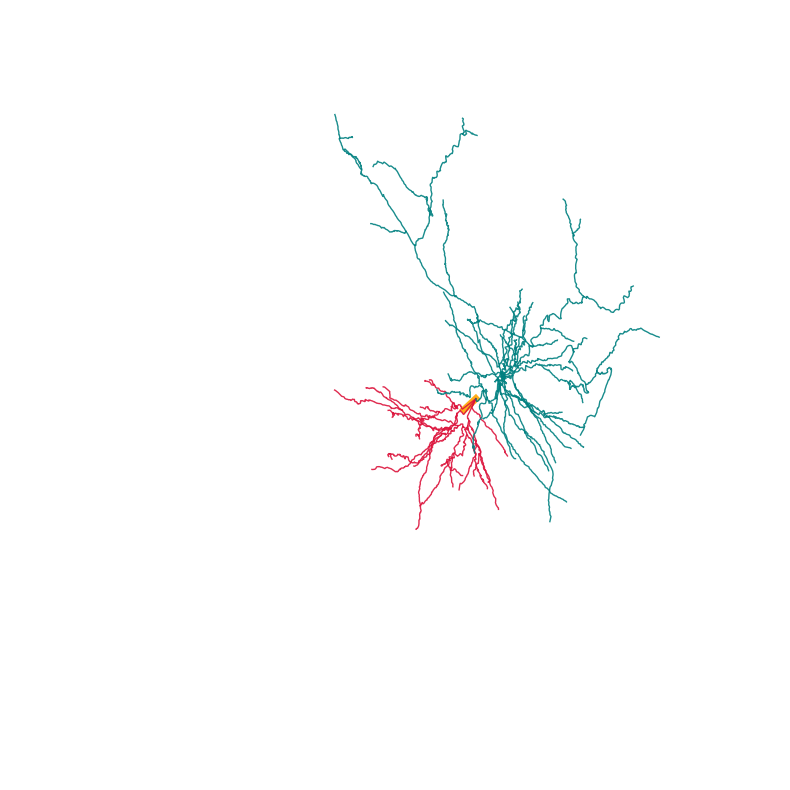

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_cell_clean_view(cell):
    fig = plt.figure(figsize=(10, 10))
    # 背景色を白に設定
    fig.patch.set_facecolor('white')
    ax = fig.add_subplot(111, projection='3d')

    for sec in h.allsec():
        name = str(sec).lower()
        
        # 配色の設定（案Aベース）
        line_w = 1.0
        if 'soma' in name:
            c = 'orange'
            line_w = 5.0  # 細胞体を強調
        elif 'apic' in name:
            c = 'teal'
        elif 'axon' in name:
            c = 'black'
        else:
            c = 'crimson'

        n3d = int(h.n3d(sec=sec))
        if n3d > 1:
            x = [h.x3d(i, sec=sec) for i in range(n3d)]
            y = [h.y3d(i, sec=sec) for i in range(n3d)]
            z = [h.z3d(i, sec=sec) for i in range(n3d)]
            
            ax.plot(x, y, z, color=c, linewidth=line_w, alpha=0.9)

    # --- グリッド、目盛り、枠線をすべて消す設定 ---
    ax.set_axis_off() 
    
    # 背景を完全に透明または白にする
    ax.set_facecolor('white')
    ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

    # アスペクト比を揃える（形を正しく保つ）
    ax.set_box_aspect((1, 1, 1)) 

# 実行
plot_cell_clean_view(cell)

検出されたapical sectionの数: 89
検出された末端（経路）の数: 45


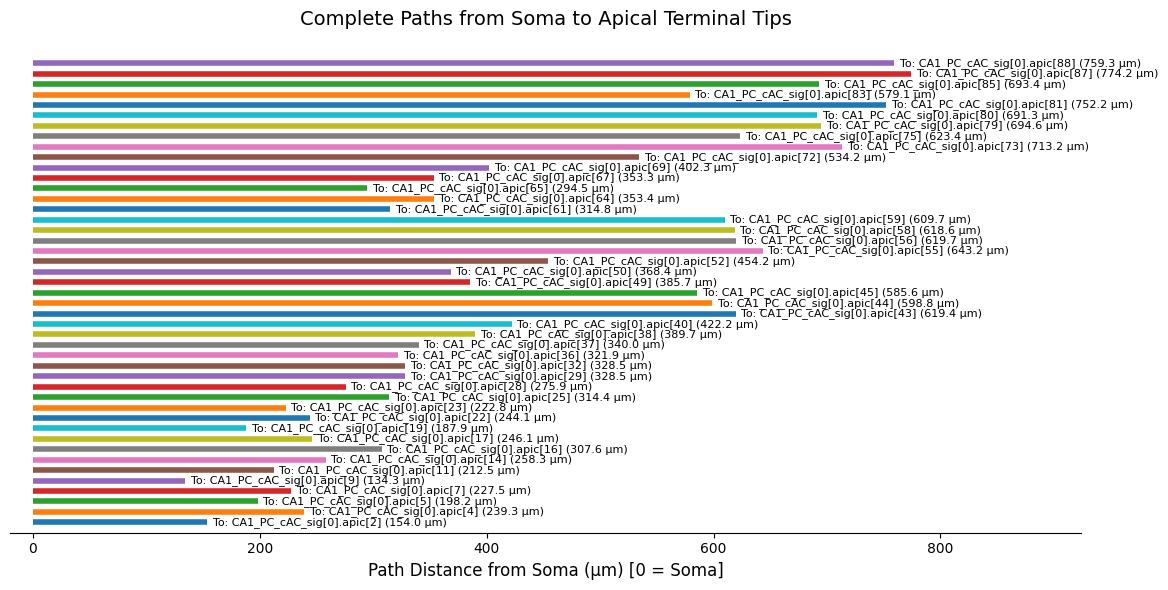

In [3]:
import matplotlib.pyplot as plt
from neuron import h

# --- 前提: cell オブジェクトの初期化 ---
h.finitialize(-65)
h.distance(0, cell.soma[0](0.5)) # Somaの中央を0とする

# 1. すべてのapicalセクションを取得
apical_sections = [sec for sec in cell.all if 'apic' in sec.name()]

# 2. 末端（Terminal tips）のセクションを抽出する
# 子供（child）を持たないセクションが「端っこ」になります
terminal_sections = []
for sec in apical_sections:
    sref = h.SectionRef(sec=sec)
    if sref.nchild() == 0:
        terminal_sections.append(sec)

# 3. 各末端について、Somaからの経路全体の長さを計算してプロット
fig, ax = plt.subplots(figsize=(12, 6))

print(f"検出されたapical sectionの数: {len(apical_sections)}")
print(f"検出された末端（経路）の数: {len(terminal_sections)}")

for y_idx, term_sec in enumerate(terminal_sections):
    # 末端セクションの終点（1）のSomaからの距離 = その経路の総外延長
    total_path_length = h.distance(term_sec(1))
    
    # 0（Soma）から total_path_length（末端）までの1本の直線を引く
    # Y軸の位置（y_idx）をずらすことで、重なりを防ぐ
    ax.plot([0, total_path_length], [y_idx, y_idx], linewidth=4, solid_capstyle='butt')
    
    # どの末端に向かう経路（パス）なのかが分かるように、末端の名前をラベルする
    ax.text(total_path_length + 5, y_idx, f"To: {term_sec.name()} ({total_path_length:.1f} µm)", 
            ha='left', va='center', fontsize=8)

# --- 4. グラフの装飾 ---
ax.set_yticks([])
ax.get_yaxis().set_visible(False)

ax.set_xlabel("Path Distance from Soma (µm) [0 = Soma]", fontsize=12)
ax.set_title("Complete Paths from Soma to Apical Terminal Tips", fontsize=14, pad=20)

# 枠線の整理
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# グラフの範囲調整
max_len = max([h.distance(sec(1)) for sec in terminal_sections]) if terminal_sections else 100
ax.set_xlim(-20, max_len + 150) # ラベルが見切れないように広めに確保
ax.set_ylim(-1, len(terminal_sections))

plt.tight_layout()
plt.show()

検出された末端（経路）の数: 45


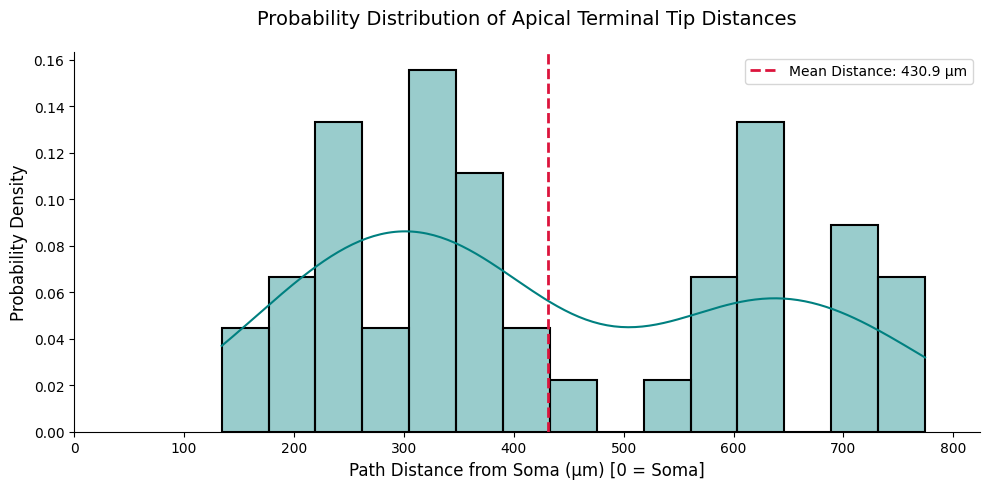

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns  # 確率密度関数（KDE）をきれいに描くために使用
from neuron import h

# --- 前提: cell オブジェクトの初期化 ---
h.finitialize(-65)
h.distance(0, cell.soma[0](0.5)) # Somaの中央を0とする

# 1. すべてのapicalセクションを取得
apical_sections = [sec for sec in cell.all if 'apic' in sec.name()]

# 2. 末端（Terminal tips）のセクションを抽出
terminal_sections = [sec for sec in apical_sections if h.SectionRef(sec=sec).nchild() == 0]

# --- 3. 各末端のSomaからの総経路長（Path Length）をリストに格納 ---
path_lengths = [h.distance(term_sec(1)) for term_sec in terminal_sections]

print(f"検出された末端（経路）の数: {len(path_lengths)}")

# --- 4. 確率分布のプロット ---
fig, ax = plt.subplots(figsize=(10, 5))

if path_lengths:
    # Seabornを使用したカーネル密度推定(KDE) + ヒストグラムによる確率分布の描画
    # stat='probability' にすることで、縦軸が確率（総和が1、または割合）になります
    sns.histplot(path_lengths, kde=True, stat='probability', color='teal', 
                 bins=15, alpha=0.4, linewidth=1.5, ax=ax)
    
    # 【オプション】もしSeabornを使わない場合は、下の行のコメントアウトを解除し、上をコメントアウトしてください
    # ax.hist(path_lengths, bins=15, density=True, color='teal', alpha=0.6, edgecolor='white')

    # 平均値や中央値などの代表値を縦線で入れると、論文の図として説得力が増します
    import numpy as np
    mean_val = np.mean(path_lengths)
    ax.axvline(mean_val, color='crimson', linestyle='--', linewidth=2, 
               label=f'Mean Distance: {mean_val:.1f} µm')
    ax.legend(loc='upper right')

# --- 5. グラフの装飾（前回のコードと横軸のスケール・思想を統一） ---
ax.set_xlabel("Path Distance from Soma (µm) [0 = Soma]", fontsize=12)
ax.set_ylabel("Probability Density", fontsize=12)
ax.set_title("Probability Distribution of Apical Terminal Tip Distances", fontsize=14, pad=20)

# 前回の横軸の見た目に合わせる（枠線の整理）
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# 横軸の範囲を、前回の直線プロットと揃えるための設定
if path_lengths:
    max_len = max(path_lengths)
    ax.set_xlim(0, max_len + 50)  # 0スタートに固定

plt.tight_layout()
plt.show()

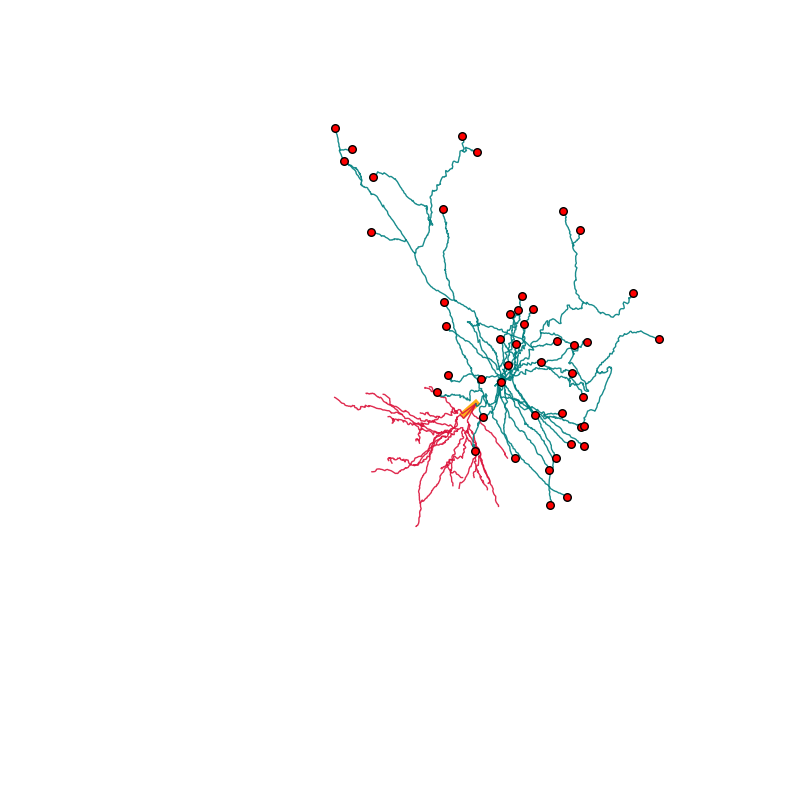

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from neuron import h

def plot_cell_clean_view(cell):
    fig = plt.figure(figsize=(10, 10))
    # 背景色を白に設定
    fig.patch.set_facecolor('white')
    ax = fig.add_subplot(111, projection='3d')

    # --- 1. すべてのセクションをデフォルト色で描画する既存のループ ---
    for sec in h.allsec():
        name = str(sec).lower()
        
        # 配色の設定（元の設定を維持）
        line_w = 1.0
        if 'soma' in name:
            c = 'orange'
            line_w = 5.0  # 細胞体を強調
        elif 'apic' in name:
            c = 'teal'
        elif 'axon' in name:
            c = 'black'
        else:
            c = 'crimson'

        n3d = int(h.n3d(sec=sec))
        if n3d > 1:
            x = [h.x3d(i, sec=sec) for i in range(n3d)]
            y = [h.y3d(i, sec=sec) for i in range(n3d)]
            z = [h.z3d(i, sec=sec) for i in range(n3d)]
            
            ax.plot(x, y, z, color=c, linewidth=line_w, alpha=0.9)

    # --- 2. 末端セクションの「先端（Tip）」に点をプロットする追加処理 ---
    
    # Apicalの末端セクションを検出（子供を持たない）
    apic_secs = [sec for sec in cell.all if 'apic' in str(sec).lower()]
    terminal_secs = [sec for sec in apic_secs if h.SectionRef(sec=sec).nchild() == 0]

    # 点の座標を格納するリスト
    tip_x, tip_y, tip_z = [], [], []

    for sec in terminal_secs:
        n3d = int(h.n3d(sec=sec))
        if n3d > 0:
            # 各セクションの最後の3D点の座標を取得
            tip_x.append(h.x3d(n3d - 1, sec=sec))
            tip_y.append(h.y3d(n3d - 1, sec=sec))
            tip_z.append(h.z3d(n3d - 1, sec=sec))

    # 末端点を散布図（Scatter plot）としてプロット
    if tip_x:
        ax.scatter(tip_x, tip_y, tip_z, 
                   color='red',        # 点の色（例: 赤）
                   s=30,               # 点のサイズ
                   marker='o',         # 点の形（丸）
                   alpha=1.0,          # 透明度なし
                   edgecolors='black', # 点の枠線を黒にして見やすく
                   depthshade=False,    # 3Dの影を付けず、鮮明に
                   label='Terminal Tips')

    # --- グリッド、目盛り、枠線をすべて消す設定 ---
    ax.set_axis_off() 
    
    # 背景を完全に透明または白にする
    ax.set_facecolor('white')
    ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

    # アスペクト比を揃える（形を正しく保つ）
    ax.set_box_aspect((1, 1, 1)) 
    
    # 凡例を表示したい場合は、以下のコメントアウトを解除
    # ax.legend()

    plt.show()

# 実行
plot_cell_clean_view(cell)

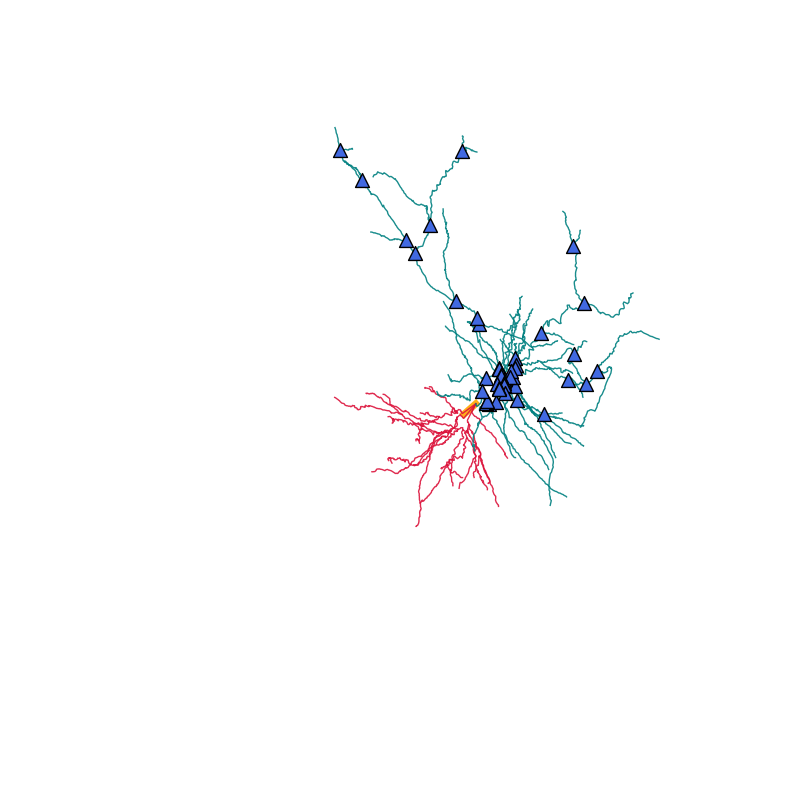

In [6]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from neuron import h

def plot_cell_with_bifurcations(cell):
    fig = plt.figure(figsize=(10, 10))
    fig.patch.set_facecolor('white')
    ax = fig.add_subplot(111, projection='3d')

    # --- 1. すべてのセクションをデフォルト色で描画 ---
    for sec in h.allsec():
        name = str(sec).lower()
        line_w = 1.0
        if 'soma' in name:
            c = 'orange'
            line_w = 5.0
        elif 'apic' in name:
            c = 'teal'
        elif 'axon' in name:
            c = 'black'
        else:
            c = 'crimson'

        n3d = int(h.n3d(sec=sec))
        if n3d > 1:
            x = [h.x3d(i, sec=sec) for i in range(n3d)]
            y = [h.y3d(i, sec=sec) for i in range(n3d)]
            z = [h.z3d(i, sec=sec) for i in range(n3d)]
            ax.plot(x, y, z, color=c, linewidth=line_w, alpha=0.9)

    # --- 2. 枝分かれ点（Bifurcation points）の検出とプロット ---
    apic_secs = [sec for sec in cell.all if 'apic' in str(sec).lower()]
    bif_x, bif_y, bif_z = [], [], []

    for sec in apic_secs:
        sref = h.SectionRef(sec=sec)
        # 子供の数が2つ以上の場合、このセクションの終端(1)が枝分かれ点となる
        if sref.nchild() >= 2:
            n3d = int(h.n3d(sec=sec))
            if n3d > 0:
                # セクションの最後の3D座標を取得
                bif_x.append(h.x3d(n3d - 1, sec=sec))
                bif_y.append(h.y3d(n3d - 1, sec=sec))
                bif_z.append(h.z3d(n3d - 1, sec=sec))

    # 枝分かれ点を散布図としてプロット（青色の大きな点）
    if bif_x:
        ax.scatter(bif_x, bif_y, bif_z, 
                   color='royalblue',   # 枝分かれ点は青
                   s=100,               # サイズ
                   marker='^',         # 目立たせるために三角マーカー（丸 'o' でも可）
                   alpha=1.0, 
                   edgecolors='black', 
                   depthshade=False,
                   label='Bifurcation Points')

    # --- グラフの装飾 ---
    ax.set_axis_off() 
    ax.set_facecolor('white')
    ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax.set_box_aspect((1, 1, 1)) 
    
    plt.show()

# 実行
plot_cell_with_bifurcations(cell)

検出された枝分かれ点の数: 44


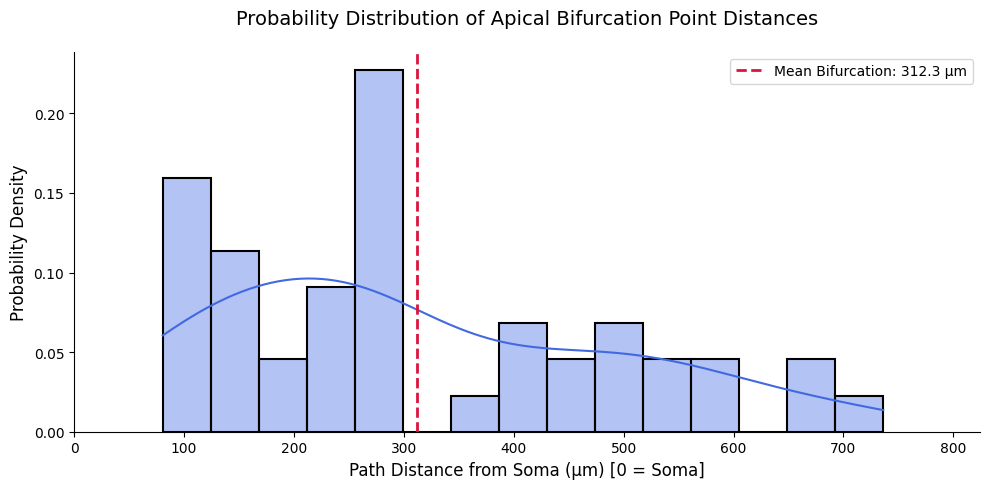

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from neuron import h

# --- 初期化 ---
h.finitialize(-65)
h.distance(0, cell.soma[0](0.5)) 

# 1. 枝分かれセクションの抽出と距離計算
apical_sections = [sec for sec in cell.all if 'apic' in sec.name()]
bifurcation_distances = []

for sec in apical_sections:
    sref = h.SectionRef(sec=sec)
    if sref.nchild() >= 2:
        # 枝分かれ点（セクションの終端1）のSomaからの距離を取得
        dist = h.distance(sec(1))
        bifurcation_distances.append(dist)

print(f"検出された枝分かれ点の数: {len(bifurcation_distances)}")

# 2. 確率分布のプロット
fig, ax = plt.subplots(figsize=(10, 5))

if bifurcation_distances:
    # 確率分布の描画（末端の時と統一感を出すため色を royalblue に変更）
    sns.histplot(bifurcation_distances, kde=True, stat='probability', color='royalblue', 
                 bins=15, alpha=0.4, linewidth=1.5, ax=ax)
    
    # 平均値のライン
    mean_bif = np.mean(bifurcation_distances)
    ax.axvline(mean_bif, color='crimson', linestyle='--', linewidth=2, 
               label=f'Mean Bifurcation: {mean_bif:.1f} µm')
    ax.legend(loc='upper right')

# --- グラフの装飾（前回と完全に統一） ---
ax.set_xlabel("Path Distance from Soma (µm) [0 = Soma]", fontsize=12)
ax.set_ylabel("Probability Density", fontsize=12)
ax.set_title("Probability Distribution of Apical Bifurcation Point Distances", fontsize=14, pad=20)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# 横軸の最大値を揃えるため、セルの最大外延長を考慮してマージンを設定
all_apic_dists = [h.distance(sec(1)) for sec in apical_sections]
max_len = max(all_apic_dists) if all_apic_dists else 100
ax.set_xlim(0, max_len + 50)

plt.tight_layout()
plt.show()

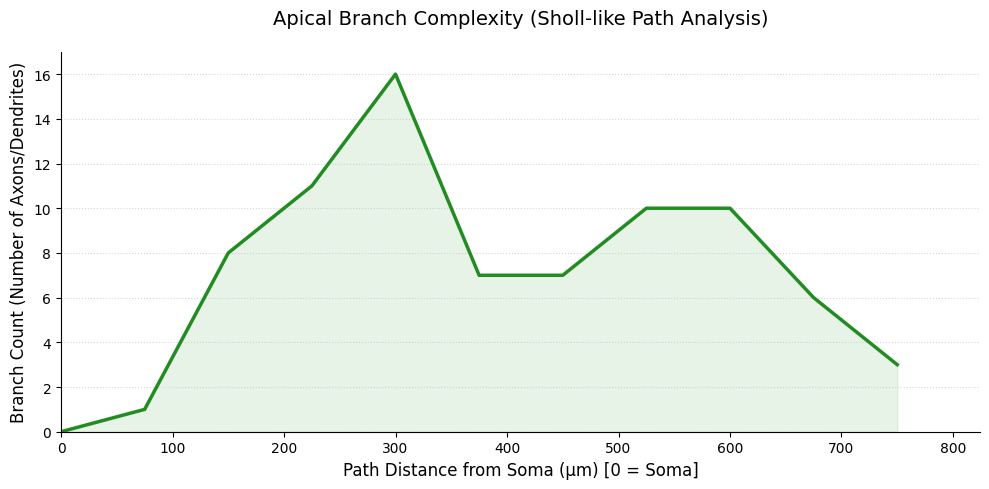

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from neuron import h

# --- 初期化 ---
h.finitialize(-65)
h.distance(0, cell.soma[0](0.5)) 

# 1. すべてのapicalセクションを取得
apical_sections = [sec for sec in cell.all if 'apic' in sec.name()]

# 各セクションの「始点」と「終点」の距離をあらかじめ計算しておく
sec_ranges = []
for sec in apical_sections:
    dist_start = h.distance(sec(0))
    dist_end = h.distance(sec(1))
    # 念のため、start < end になるように格納
    sec_ranges.append((min(dist_start, dist_end), max(dist_start, dist_end)))

# 2. 横軸（距離）のサンプリングポイントを設定
# 0 µm から apical の最遠位点まで、10 µm 刻みで調べる
max_len = max([r[1] for r in sec_ranges]) if sec_ranges else 100
distance_grid = np.arange(0, max_len + 50, 75)

# 3. 各距離における枝の数をカウント
branch_counts = []
for d in distance_grid:
    # 距離 d が、セクションの始点と終点の間に含まれている数をカウント
    count = sum(1 for start, end in sec_ranges if start <= d <= end)
    branch_counts.append(count)

# --- 4. グラフのプロット ---
fig, ax = plt.subplots(figsize=(10, 5))

# 枝の数は連続値（確率密度）ではなく「個数」なので、折れ線グラフ（またはステップ図）で描画します
ax.plot(distance_grid, branch_counts, color='forestgreen', linewidth=2.5, label='Number of Branches')
ax.fill_between(distance_grid, branch_counts, color='forestgreen', alpha=0.1) # 視覚的な塗りを追加

# 5. グラフの装飾（これまでのコードと完全にスケールを統一）
ax.set_xlabel("Path Distance from Soma (µm) [0 = Soma]", fontsize=12)
ax.set_ylabel("Branch Count (Number of Axons/Dendrites)", fontsize=12)
ax.set_title("Apical Branch Complexity (Sholl-like Path Analysis)", fontsize=14, pad=20)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlim(0, max_len + 50)
ax.set_ylim(0, max(branch_counts) + 1 if branch_counts else 5)
ax.grid(axis='y', linestyle=':', alpha=0.5) # 個数が見やすいように横方向の補助線を追加

plt.tight_layout()
plt.show()